Dataset Preview:
          x         y
0  0.496714  4.861736
1  0.647689  6.523030
2 -0.234153  4.765863
3  1.579213  5.767435
4 -0.469474  5.542560


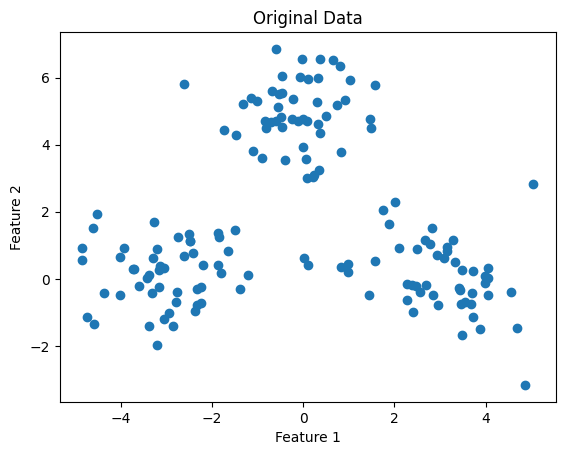

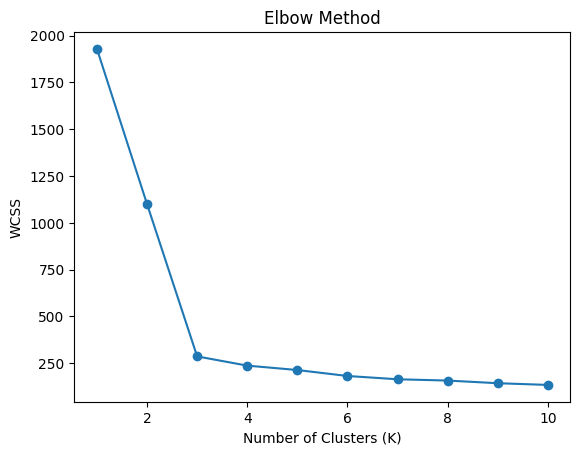

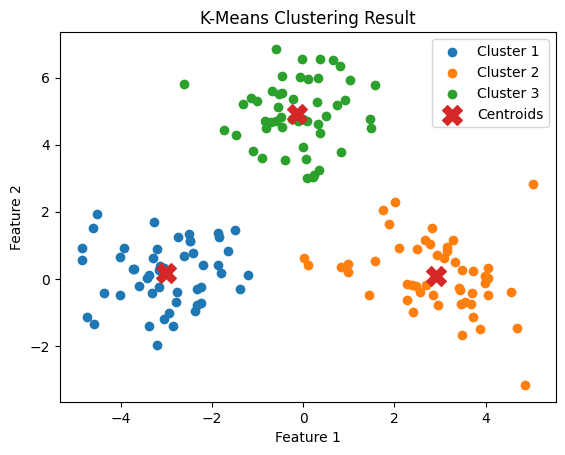

In [3]:
# ==============================
# K-Means Clustering (2D Dataset)
# ==============================

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ------------------------------
# Load Dataset
# ------------------------------
data = pd.read_csv("dataset.csv")

print("Dataset Preview:")
print(data.head())

# Use all columns (2D dataset)
X = data.iloc[:, :].values

# ------------------------------
# Step 1: Visualize Raw Data
# ------------------------------
plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ------------------------------
# Step 2: Elbow Method (Find Best K)
# ------------------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

# ------------------------------
# Step 3: Apply K-Means
# ------------------------------
k = 3   # choose based on elbow graph
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)

y_kmeans = kmeans.fit_predict(X)

# ------------------------------
# Step 4: Visualize Clusters
# ------------------------------
plt.figure()

# Plot clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], label='Cluster 3')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200,
            marker='X',
            label='Centroids')

plt.title("K-Means Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()